Estrazione di un campione di 10.000 utenti...
Trasformazione dei dati in corso...
Calcolo del Silhouette Score in corso...
 -> K=2 completato (Silhouette Score: 0.0817)
 -> K=3 completato (Silhouette Score: 0.0666)
 -> K=4 completato (Silhouette Score: 0.0625)
 -> K=5 completato (Silhouette Score: 0.0587)
 -> K=6 completato (Silhouette Score: 0.0574)
 -> K=7 completato (Silhouette Score: 0.0562)
 -> K=8 completato (Silhouette Score: 0.0560)
 -> K=9 completato (Silhouette Score: 0.0560)
 -> K=10 completato (Silhouette Score: 0.0558)


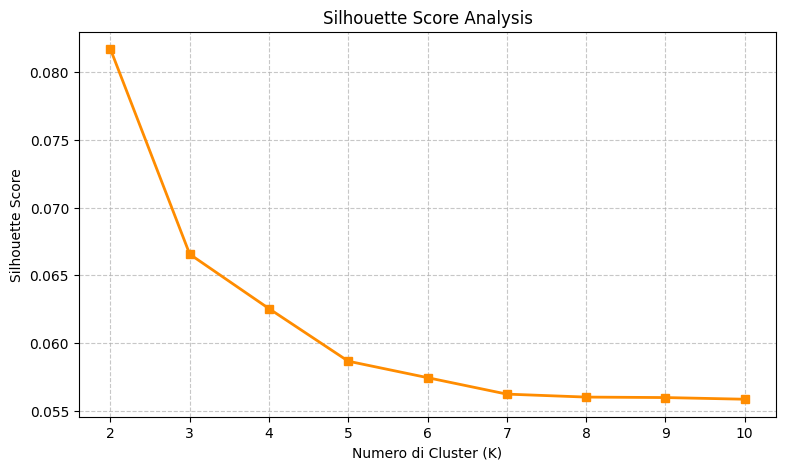

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import sys
import os

# 1. Capiamo dove si trova il notebook
cartella_corrente = os.getcwd()

# 2. Facciamo UN PASSO INDIETRO per trovare la cartella principale del progetto
cartella_principale = os.path.dirname(cartella_corrente)

# 3. Facciamo UN ALTRO PASSO INDIETRO per trovare la root principale
cartella_root = os.path.dirname(cartella_principale)

# 4. Aggiungiamo la cartella principale al radar di Python
if cartella_principale not in sys.path:
    sys.path.append(cartella_principale)

# --- FIX: IMPORTIAMO DALLA CARTELLA UTILS ---
from utils.preprocessing import build_preprocessor

# --- FIX: PERCORSO CORRETTO PER IL DATASET IN data/processed ---
dataset_path = os.path.join(cartella_root, 'data', 'processed', 'adapted_dataset.csv')
print(f"Lettura del dataset da: {dataset_path}")
df_users = pd.read_csv(dataset_path)

# Campionamento per evitare tempi biblici
# Allineato il print a 50.000 come impostato nel codice
print("Estrazione di un campione di 50.000 utenti...")
if len(df_users) > 50000:
    df_sample = df_users.sample(n=50000, random_state=42)
else:
    df_sample = df_users.copy()

print("Trasformazione dei dati in corso...")
preprocessor = build_preprocessor()
X_processed = preprocessor.fit_transform(df_sample)

# Calcolo del Silhouette Score
silhouette_scores = []
K_range = range(2, 11)

print("Calcolo del Silhouette Score in corso (potrebbe richiedere qualche minuto su 50k righe)...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_processed)
    score = silhouette_score(X_processed, labels)
    silhouette_scores.append(score)
    print(f" -> K={k} completato (Silhouette Score: {score:.4f})")

# Disegno del grafico
plt.figure(figsize=(9, 5))
plt.plot(K_range, silhouette_scores, marker='s', linestyle='-', color='darkorange', linewidth=2)
plt.title('Silhouette Score Analysis')
plt.xlabel('Numero di Cluster (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)

# MOSTRA IL GRAFICO INVECE DI SALVARLO
plt.show()